# Phase 2: Preprocessing Pipeline, Modellierung, Hyperparameter-Tuning & MLflow Tracking

## Ziele dieses Notebooks:
* **Daten laden:** Aufbereiteten Datensatz `data/data_processed.csv` importieren.
* **Preprocessing Pipeline aufbauen:** Numerische Spalten (Fragen N1-A4 + Age) median-imputieren und skalieren (`StandardScaler`); kategoriale Spalten (`gender`, `hand`) mode-imputieren und one-hot-kodieren (`OneHotEncoder`).
* **Baseline-Vergleich:** Mehrere Modelle (z. B. RandomForest, LogisticRegression) per 5-Fold Cross-Validation anhand des `F1-Macro`-Scores evaluieren.
* **Hyperparameter-Tuning & Experiment Tracking:** Ausgewählte Modelle tunen und jeden Run mit Parametern, Metriken und Modell-Artefakten in **MLflow** aufzeichnen.
* **Champion-Wahl:** Bestes Modell für das spätere Deployment in der Streamlit-App identifizieren.

In [35]:
# Imports & Daten laden
import pandas as pd
import numpy as np

# MLflow Tracking einrichten (lokale SQLite-Datenbank)
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("personality-prediction")

# Daten aus der EDA-Phase laden
df = pd.read_csv("data/data_processed.csv")

# Separation von Features (X) und Target (y)
X = df.drop(columns=["target"])
y = df["target"]

print("Features Shape:", X.shape)
print("Target Klassen:", y.unique())

Features Shape: (19636, 22)
Target Klassen: <ArrowStringArray>
['Resilient', 'Moderate', 'Overcontroller', 'Undercontroller']
Length: 4, dtype: str


In [36]:
# Scikit-Learn Preprocessing Pipeline definieren
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Spalten nach Typen trennen
item_cols = [c for c in X.columns if c not in ["age", "gender", "hand"]]
numeric_features = item_cols + ["age"]
categorical_features = ["gender", "hand"]

# Pipelines für numerische und kategoriale Features
# Null-Werte mit dem Mittelwert (nicht Arith.Mittel)
# Der Mittelwert (arithmetisches Mittel) reagiert extrem
# empfindlich auf Ausreißer, z.B. eine Person von 99Jh. 
# und dann Standardskalierung: (zieht von jedem Wert den Mittelwert ab und teilt durch die Standardabweichung 
# Das Ergebnis sind Werte, die typischerweise im Bereich von -3 bis +3.
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
# Null-Werte mit der häufigsten Ausprägung und
# Ohne math. Mittelwert ist 'Modus' mathematisch
# das einzige sinnvolle Maß über alle Datensätze
# Die dadurch verstärkte Tendenz im Urspungsdatensatz
# ist mit 24 fehlende Werten bei 19.636 Zeilen hat (also ca. 0,12 %).
# unproblematisch.
# Anschließend ['Male', 'Female', 'Other'] ['Right','Left', 'Both']
# auf Spalten mit 1-0 encoden
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Zusammenführung im ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

print("Preprocessing Pipeline erfolgreich definiert!")

Preprocessing Pipeline erfolgreich definiert!


In [37]:
# Das entstandene DataFrame mal anschauen :-D
# 1. Daten durch den Preprocessor transformieren
X_transformed = preprocessor.fit_transform(X)

# 2. Die neuen Spaltennamen aus dem Preprocessor auslesen
feature_names = preprocessor.get_feature_names_out()

# 3. Als lesbares DataFrame verpacken und anzeigen
df_transformed = pd.DataFrame(X_transformed, columns=feature_names)

print("Shape vorher (raw):       ", X.shape)
print("Shape nachher (prep):     ", df_transformed.shape)

# Erste 5 Zeilen der aufbereiteten Daten anzeigen
df_transformed.head()


Shape vorher (raw):        (19636, 22)
Shape nachher (prep):      (19636, 26)


,num__N6,num__N8,num__N7,num__N1,num__N9,num__N10,num__N3,num__N5,num__E3,num__N2,...,num__A4,num__E10,num__E9,num__age,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__hand_Both,cat__hand_Left,cat__hand_Right
0,-1.499924,-1.335017,-1.656217,-1.728914,-1.643855,-1.396829,-1.618815,-1.532865,1.280244,1.499463,...,0.927745,-1.983074,1.365147,2.311382,0.0,1.0,0.0,0.0,0.0,1.0
1,0.772997,-0.594581,-0.117212,-0.964401,-0.873479,0.888659,0.137958,0.038574,-0.337236,-0.200260,...,-0.029544,1.084791,-1.500199,1.706222,1.0,0.0,0.0,0.0,0.0,1.0
2,1.530637,1.626727,1.421793,1.329137,1.437647,1.650488,1.016345,1.610012,-1.954716,-1.899984,...,0.927745,-1.983074,1.365147,-1.060223,1.0,0.0,0.0,0.0,0.0,1.0
3,1.530637,1.626727,1.421793,1.329137,0.667272,1.650488,0.137958,0.824293,-1.145976,0.649601,...,-0.029544,1.084791,0.648811,-0.627966,1.0,0.0,0.0,0.0,0.0,1.0
4,0.015357,0.145855,-0.117212,-0.199888,-0.103104,0.888659,-0.740429,0.038574,-0.337236,-0.200260,...,0.927745,1.084791,-0.067526,-0.109257,1.0,0.0,0.0,0.0,0.0,1.0


### Wir haben 6 Neue Kategorie-Spalten und die beiden Ausgangsspalten Gender & Hand entfernt also 22 zu => 26 Spalten

In [38]:
# Baseline-Modellvergleich & MLflow
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Pipeline für Logistic Regression definieren
# LogisticRegression weil die Zielklassen als Z-Scores der OCEAN Eigenschaften
# definiert sind; Z-Scores sind gewichtete lineare Summen/Kombinationen
# Logistic Regression ist ein lineares Modell – sie modelliert solche linearen Zusammenhänge
# mathematisch perfekt und ohne Overhead. Der bei KNN höher wäre
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Pipeline für Random Forest definieren
# Risiko des 'Overfitting' !?
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# 3. Baseline Evaluation mit 5-Fold Cross Validation (Metrik: f1_macro)
score_lr = cross_val_score(pipe_lr, X, y, cv=5, scoring="f1_macro").mean()
score_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring="f1_macro").mean()

print(f"Baseline Logistic Regression (F1-Macro): {score_lr:.4f}")
print(f"Baseline Random Forest       (F1-Macro): {score_rf:.4f}")

Baseline Logistic Regression (F1-Macro): 0.7685
Baseline Random Forest       (F1-Macro): 0.7466


####  Der Klassifikationsbericht im RandomForest zeigte Klassenungleichgewichte, daher wurde mit dem Attribut class_wight='balanceds' darauf eingegangen:
* Moderate bildet mit 8.452 Einträgen (42,86 %) die dominierende Masse.   
* Undercontroller stellt mit nur 2.275 Einträgen (11,54 %) die kleinste Gruppe dar.   
* Ein Random Forest optimiert standardmäßig die Gesamtzahl der korrekten Vorhersagen (Accuracy). Da Fehler bei der Mehrheitsklasse Moderate strenger „bestraft“ werden als Fehler bei der kleinen Klasse Undercontroller, tendiert der Baum dazu, unsichere Grenzfälle lieber als Moderate zu klassifizieren.

In [39]:
# Classification Report RandomForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# class_weight="balanced" eingfügt, nachdem
# 'moderate' Precision: 0.77 | Recall: 0.92 
# und
# 'undercontroller' Precision: 0.65 | Recall: 0.24
# unausgewogen 'unbalanced' waren 
model_rf = Pipeline([("preprocessor", preprocessor),
                  ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))])
model_rf.fit(X_train, y_train)
print(classification_report(y_test, model_rf.predict(X_test)))


                 precision    recall  f1-score   support

       Moderate       0.85      0.82      0.83      1682
 Overcontroller       0.80      0.91      0.85       565
      Resilient       0.95      0.94      0.95      1230
Undercontroller       0.55      0.52      0.53       451

       accuracy                           0.84      3928
      macro avg       0.78      0.80      0.79      3928
   weighted avg       0.84      0.84      0.84      3928



In [40]:
# Classification Report LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# class_weight="balanced" eingfügt, nachdem
# 'moderate' Precision: 0.82 | Recall: 0.90 
# und
# 'undercontroller' Precision: 0.52 | Recall: 0.31
# ebenfalls unausgewogen 'unbalanced' waren 
model_lr_b = Pipeline([("preprocessor", preprocessor),
                  ("classifier",  LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])
model_lr_b.fit(X_train, y_train)
print(classification_report(y_test, model_lr_b.predict(X_test)))


                 precision    recall  f1-score   support

       Moderate       0.90      0.72      0.80      1682
 Overcontroller       0.70      0.87      0.77       565
      Resilient       1.00      1.00      1.00      1230
Undercontroller       0.46      0.66      0.54       451

       accuracy                           0.82      3928
      macro avg       0.76      0.81      0.78      3928
   weighted avg       0.85      0.82      0.83      3928



* Logistic Regression zeigt mit class_weight="balanced" ein klassisches Muster: Durch das extreme Bestrafen von Fehlern bei Undercontroller hat das Modell nun einen Recall von 0,66 (vorher 0,31), driftet aber bei Moderate in Precision/Recall ab und neigt dazu, Moderate in Undercontroller umzudeuten
* Da wir keine synthetischen Daten mittels SMOTE (Synthetic Minority Over-sampling Technique) hinzufügen wollen, versuchen wir es mal mit Schwellenwert-Anpassung (Threshold Tuning) und geben zusätzliches *Gewicht* auf die Zielausprägung 'Undercontroller'

In [41]:
## Angepasste Version des Klassifizierungsberichtes für LogisticRegression
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 1. Pipeline ohne extremes class_weight trainieren (oder ungewichtete Baseline nutzen)
model_lr_t = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
model_lr_t.fit(X_train, y_train)

# 2. Wahrscheinlichkeiten für alle Klassen holen
y_probs = model_lr_t.predict_proba(X_test)
classes = model_lr_t.classes_  # Liste der Klassennamen (z.B. ['Moderate', 'Overcontroller', ...])

# 3. Schwellenwert-Anpassung über Multiplikatoren/Weights
# Wir geben der Klasse 'Undercontroller' einen künstlichen 'Push' (z.B. Faktor 1.6 - 2.0)
class_weights_dict = {
    "Moderate": 1.0,
    "Overcontroller": 1.0,
    "Resilient": 1.0,
    "Undercontroller": 1.8  # Erhöht die Wahrscheinlichkeit für Undercontroller gezielt
}

# Gewichte auf die Wahrscheinlichkeiten anwenden
weighted_probs = y_probs * np.array([class_weights_dict[c] for c in classes])

# Die Klasse mit dem höchsten gewichteten Wert auswählen
custom_preds = classes[np.argmax(weighted_probs, axis=1)]

# 4. Angepassten Classification Report ausgeben
print(classification_report(y_test, custom_preds))

                 precision    recall  f1-score   support

       Moderate       0.85      0.87      0.86      1682
 Overcontroller       0.78      0.79      0.79       565
      Resilient       1.00      1.00      1.00      1230
Undercontroller       0.55      0.50      0.52       451

       accuracy                           0.86      3928
      macro avg       0.79      0.79      0.79      3928
   weighted avg       0.85      0.86      0.85      3928



* Bei KNN waren ähnliche Ungleigewichte zu beobachten, doch auch durch die angepasste Gewichtung hat nur wenig Änderung gebracht

In [42]:
# Classification Report KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model_kn = Pipeline([("preprocessor", preprocessor),
                  ("classifier",  KNeighborsClassifier(n_neighbors=5, weights="distance"))])
model_kn.fit(X_train, y_train)
print(classification_report(y_test, model_kn.predict(X_test)))


                 precision    recall  f1-score   support

       Moderate       0.79      0.83      0.81      1682
 Overcontroller       0.80      0.90      0.85       565
      Resilient       0.91      0.92      0.92      1230
Undercontroller       0.51      0.30      0.38       451

       accuracy                           0.81      3928
      macro avg       0.75      0.74      0.74      3928
   weighted avg       0.80      0.81      0.80      3928



In [43]:
# Classification Report HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model_hg = Pipeline([("preprocessor", preprocessor),
                  ("classifier",  HistGradientBoostingClassifier(random_state=42))])
model_hg.fit(X_train, y_train)
print(classification_report(y_test, model_hg.predict(X_test)))


                 precision    recall  f1-score   support

       Moderate       0.83      0.90      0.86      1682
 Overcontroller       0.86      0.86      0.86       565
      Resilient       0.98      0.97      0.98      1230
Undercontroller       0.62      0.43      0.51       451

       accuracy                           0.86      3928
      macro avg       0.82      0.79      0.80      3928
   weighted avg       0.86      0.86      0.86      3928



In [44]:
# Optimierung mir RandomSearchCV für HistGradientBoostingClassifier
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 1. Pipeline mit HistGradientBoostingClassifier aufbauen
pipe_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        class_weight="balanced",  # Berücksichtigt das Klassenungleichgewicht automatisch
        random_state=42
    ))
])

# 2. Parameter-Raum mit Präfix 'classifier__' für die Pipeline definieren
param_distributions = {
    'classifier__learning_rate': uniform(0.01, 0.15),   # Lernrate
    'classifier__max_iter': randint(100, 300),          # Anzahl der Bäume
    'classifier__max_leaf_nodes': randint(15, 63),      # Maximale Blätter pro Baum
    'classifier__min_samples_leaf': randint(10, 40),    # Mindestanzahl Samples pro Blatt
    'classifier__l2_regularization': uniform(0.0, 5.0)  # L2-Regularisierung gegen Overfitting
}


# 3. RandomizedSearchCV mit f1_macro als Zielmetrik aufsetzen
random_search = RandomizedSearchCV(
    estimator=pipe_hgb,
    param_distributions=param_distributions,
    n_iter=30,                   # 30 Kombinationen reichen für gute Ergebnisse
    cv=5,                        # 5-Fold Stratified CV
    scoring='f1_macro',          # WICHTIG: f1_macro statt accuracy!
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. Suche starten 
random_search.fit(X_train, y_train)

# 5. Bestes Modell evaluieren & Classification Report ausgeben
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Beste Parameter:", random_search.best_params_)
print(f"Bester Cross-Validation F1-Macro: {random_search.best_score_:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Beste Parameter: {'classifier__l2_regularization': np.float64(4.82627653632069), 'classifier__learning_rate': np.float64(0.1010551371530027), 'classifier__max_iter': 140, 'classifier__max_leaf_nodes': 43, 'classifier__min_samples_leaf': 24}
Bester Cross-Validation F1-Macro: 0.8038

Classification Report (Test Set):
                 precision    recall  f1-score   support

       Moderate       0.89      0.77      0.82      1682
 Overcontroller       0.83      0.90      0.87       565
      Resilient       0.97      0.97      0.97      1230
Undercontroller       0.48      0.68      0.56       451

       accuracy                           0.84      3928
      macro avg       0.79      0.83      0.81      3928
   weighted avg       0.86      0.84      0.85      3928



* Tunen des HistGradientBoostingClassifier ist eher kontraproduktiv, bzw. *teuer* da die Rechenzeit enorm angestiegen ist, ohnen dass der macro_avg bzw. f1-score wesentlich gestiegen ist. Die Accuracy ist sogar gesunken. Das ist in dem vorliegenden Fall unsinnig, daher wir beim Modellvergleich kein Tunen für HGB angewendet.

### Wir nutzen cross_val_score statt ein einfaches model.fit() 
* ** Wenn wir ein Modell nur einmal auf einem festen Train/Test-Split trainieren (fit), hängt die Bewertung stark vom Zufall ab (welche Daten landeten im Test-Set?).  
* ** ! cross_val_score führt eine 5-Fold Cross-Validation (5-fache Kreuzvalidierung) durch:   
* *** Der gesamte Datensatz wird in 5 gleich große Teile (Folds) aufgeteilt. 
* **** Durchlauf 1: Ordner 1-4 werden zum Trainieren genutzt (.fit()), Ordner 5 zum Testen (.predict()).
* **** Durchlauf 2: Ordner 1, 2, 3, 5 werden zum Trainieren genutzt, Ordner 4 zum Testen.
* **** Das wird wiederholt, bis jeder Ordner einmal als Testset diente.Am Ende berechnet cross_val_score den Durchschnitt der 5 Ergebnisse (.mean()).

In [45]:
# Zum Vergleichen werden weitere Modelle/Algorithmen angewendet
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Liste von Modellen zum Vergleichen
models = {
    "Logistic_Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "Hist_Gradient_Boosting": HistGradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights="distance")
}

# Experimente in MLflow loggen
for name, clf in models.items():
    with mlflow.start_run(run_name=name):
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ])
        
        # 5-Fold Cross-Validation
        scores = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
        mean_score = scores.mean()
        
        # In MLflow aufzeichnen
        mlflow.log_param("model_type", name)
        mlflow.log_metric("f1_macro", mean_score)
        
        print(f"Logged {name:<23} | F1-Macro: {mean_score:.4f}")


Logged Logistic_Regression     | F1-Macro: 0.7842
Logged Random_Forest           | F1-Macro: 0.7840
Logged Hist_Gradient_Boosting  | F1-Macro: 0.8006
Logged KNN                     | F1-Macro: 0.7339


* **In cross_val_score() laufen im Hintergrund automatisch folgende Schritte ab:
1. Splitting (Aufteilung): Die Daten werden in $K$ Blöcke (Folds) unterteilt (bei cv=5 also in 5 gleich große Teile). Durch die Strategie StratifiedKFold wird sichergestellt, dass das Mischungsverhältnis der 4 Zielklassen in jedem Block identisch ist.
2. fit() (Training): Das Modell wird auf $K-1$ Blöcken trainiert (z. B. auf Block 1, 2, 3 und 4).
3. predict() (Vorhersage): Das trainierte Modell sagt die Ergebnisse für den übrig gebliebenen, für das Modell unbekannten Block (z. B. Block 5) voraus.
4. Metrik berechnen: Der F1-Score wird ausschließlich auf diesem unbekannten Validierungsblock berechnet.
Dieser Prozess wird K-mal wiederholt, sodass jeder Block genau einmal als ungesehenes Test-Set dient.
* ***Was bedeutet das für unser finales Modell?
cross_val_score() dient nur zur fairen Bewertung der Modellleistung – es speichert am Ende kein einzelnes, fertiges Modell ab.
* ++Damit wir unser bestes Modell (HistGradientBoostingClassifier) später in der Streamlit-App verwenden können, führen wir als Nächstes ein explizites fit() auf den gesamten Daten durch und loggen dieses fertige Modell-Artefakt direkt in MLflow!


In [46]:
# Die "Black Box" von cross_val_score() öffnen
# Um genau zu sehen, was cross_val_score im Hintergrund tut, 
# schauen wir uns die 5 einzelnen Ergebnisse (Folds) an 
# und simulieren die Schleife einmal manuell mit StratifiedKFold.
# !?!?!?!
# Was passiert hier manuell?
# 1. Scikit-Learn teilt die Daten mit StratifiedKFold
#  (damit in jedem Fold das Verteilungverhältnis der 4 Zielklassen identisch bleibt) in 5 Häppchen:  
#  Fold 1: Trainiert auf Fold 2–5, testet auf Fold 1 => Score 1
#  Fold 2: Trainiert auf Fold 1, 3–5, testet auf Fold 2 => Score 2
#  ...usw.
# 2. Am Ende nimmt cross_val_score einfach .mean() über alle 5 Werte
from sklearn.model_selection import StratifiedKFold

# 1. Die 5 einzelnen Fold-Ergebnisse anzeigen
scores = cross_val_score(models["Hist_Gradient_Boosting"], X_transformed, y, cv=5, scoring="f1_macro")

print("--- 5-Fold Cross-Validation Details ---")
for fold, score in enumerate(scores, 1):
    print(f"Fold {fold}: F1-Macro = {score:.4f}")

print(f"\nDurchschnitt (Mean): {scores.mean():.4f}")
print(f"Standardabweichung:  {scores.std():.4f}")

--- 5-Fold Cross-Validation Details ---
Fold 1: F1-Macro = 0.8096
Fold 2: F1-Macro = 0.7950
Fold 3: F1-Macro = 0.8084
Fold 4: F1-Macro = 0.7954
Fold 5: F1-Macro = 0.7945

Durchschnitt (Mean): 0.8006
Standardabweichung:  0.0069


In [47]:
# 1. Die finale Pipeline mit dem Gewinner-Modell definieren
champion_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

# 2. Robusten CV-Score dynamisch berechnen
cv_scores = cross_val_score(champion_pipeline, X, y, cv=5, scoring="f1_macro")
champion_f1 = cv_scores.mean()

# 3. Einmalig auf allen Daten trainieren (fit)
champion_pipeline.fit(X, y)

# 4. Den Champion-Run in MLflow aufzeichnen
with mlflow.start_run(run_name="Champion_HistGradientBoosting") as run:
    # Parameter & Metrik speichern
    mlflow.log_param("model_type", "HistGradientBoosting")
    mlflow.log_metric("f1_macro", champion_f1)
    
    # Modell mit cloudpickle sichern (bewährter Standard für komplexe Pipelines)
    mlflow.sklearn.log_model(
        sk_model=champion_pipeline,
        name="model",
        serialization_format="cloudpickle"
    )
    
    # Run ID für app.py ausgeben
    champion_run_id = run.info.run_id
    print("--------------------------------------------------")
    print(f"CHAMPION MODEL ERFOLGREICH GELOGGT!")
    print(f"Deine RUN_ID lautet: {champion_run_id}")
    print("--------------------------------------------------")

2026/09/25 19:11:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--------------------------------------------------
CHAMPION MODEL ERFOLGREICH GELOGGT!
Deine RUN_ID lautet: 7544cecc331849b0ba5adc59ab03a06b
--------------------------------------------------


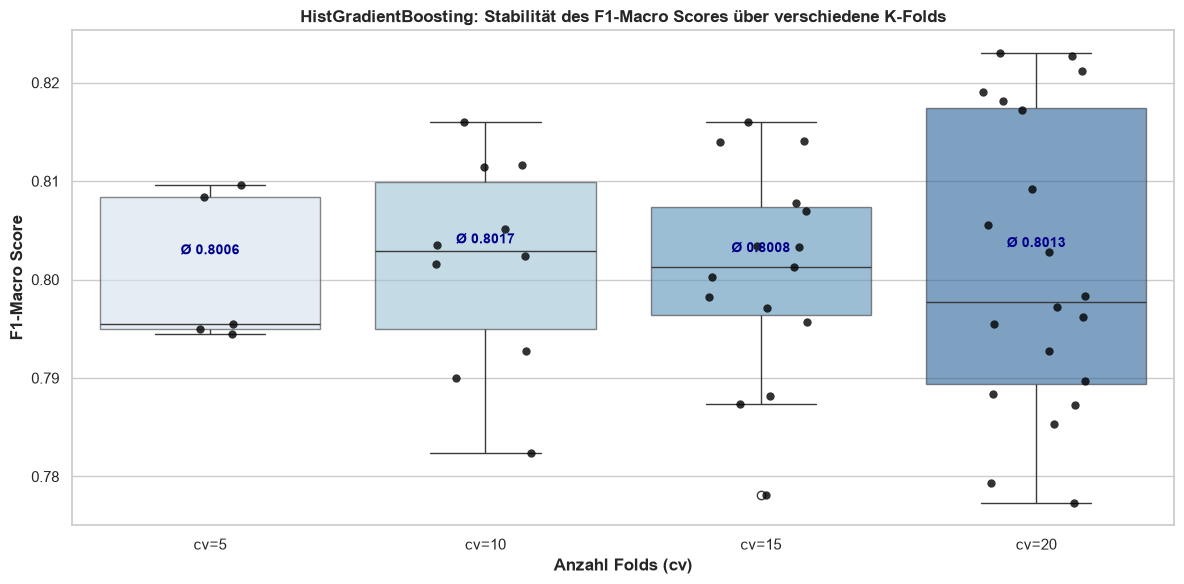

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

# 1. Pipeline definieren
champion_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

# 2. Verschiedene cv-Werte testen und Ergebnisse sammeln
cv_values = [5, 10, 15, 20]
fold_results = []

for k in cv_values:
    # Cross-Validation durchführen
    scores = cross_val_score(champion_pipe, X, y, cv=k, scoring="f1_macro", n_jobs=-1)
    
    # Ergebnisse für das Plotten aufbereiten
    for fold_idx, score in enumerate(scores, 1):
        fold_results.append({
            "K_Folds": f"cv={k}",
            "Fold": fold_idx,
            "F1_Macro": score
        })

df_folds = pd.DataFrame(fold_results)

# 3. Visualisierung
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Boxplot zeigt die Verteilung/Streuung, Stripplot die einzelnen Punkte
ax = sns.boxplot(x="K_Folds", y="F1_Macro", hue="K_Folds", data=df_folds, palette="Blues", boxprops=dict(alpha=0.6))
sns.stripplot(x="K_Folds", y="F1_Macro", data=df_folds, color="black", size=6, jitter=0.2, alpha=0.8)

# Mittelwerte einzeichnen und beschriften
means = df_folds.groupby("K_Folds")["F1_Macro"].mean()
for i, k_str in enumerate([f"cv={k}" for k in cv_values]):
    mean_val = means[k_str]
    ax.text(i, mean_val + 0.002, f"Ø {mean_val:.4f}", horizontalalignment='center', size=10, color='darkblue', weight='semibold')

plt.title("HistGradientBoosting: Stabilität des F1-Macro Scores über verschiedene K-Folds", fontsize=12, fontweight="bold")
plt.xlabel("Anzahl Folds (cv)", fontweight="bold")
plt.ylabel("F1-Macro Score", fontweight="bold")

plt.tight_layout()
plt.savefig("data/kfold_variance_analysis.png", dpi=300)
plt.show()

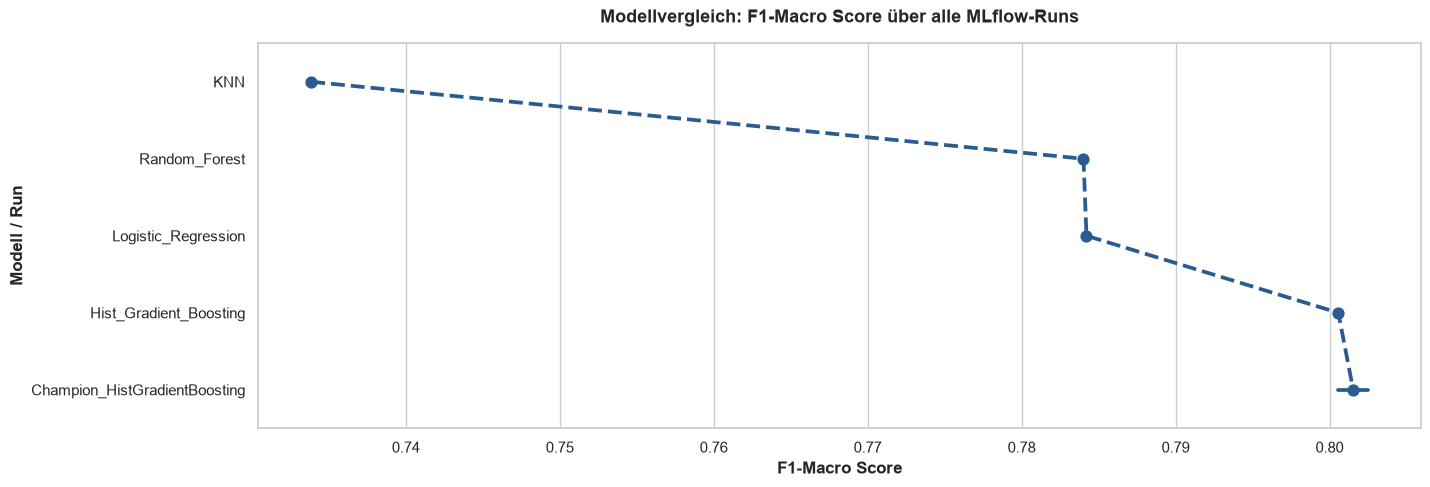

In [64]:
# Visualisierung der Evaluierungsergebnisse aus der MLflow-Datenbank
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Alle Runs aus dem aktuellen MLflow-Experiment abrufen

# 1. Runs abrufen und auf die letzten 10 beschränken
experiment = mlflow.get_experiment_by_name("personality-prediction")
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    max_results=10,
    order_by=["attribute.start_time DESC"]
)

# 2. Relevante Spalten filtern & Spaltennamen säubern
results_df = runs_df[["tags.mlflow.runName", "metrics.f1_macro"]].dropna()
results_df.columns = ["Model", "F1_Macro"]

# Sortieren nach F1-Macro Score für eine schöne Darstellung
results_df = results_df.sort_values(by="F1_Macro", ascending=True)

# 3. Streu-/Balkendiagramm zeichnen (Visualisierung)
plt.figure(figsize=(15, 5))
sns.set_theme(style="whitegrid")

# Punkteplot (Scatter) kombiniert mit einer dezenten Linie
ax = sns.pointplot(
    data=results_df, 
    x="F1_Macro", 
    y="Model", 
    color="#2b5c8f", 
    markers="o", 
    linestyles="--"
)

# Werte direkt an den Punkten einblenden
# for i, row in results_df.reset_index(drop=True).iterrows():
#     ax.text(
#         row["F1_Macro"] + 0.03, 
#         i, 
#         f'{row["F1_Macro"]:.4f}', 
#         va='center', 
#         fontweight='bold', 
#         color='#1a334e'
#     )

plt.title("Modellvergleich: F1-Macro Score über alle MLflow-Runs", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("F1-Macro Score", fontweight="bold")
plt.ylabel("Modell / Run", fontweight="bold")
#plt.xlim(results_df["F1_Macro"].min() - 0.02, results_df["F1_Macro"].max() + 0.04)

#plt.tight_layout()
plt.savefig("data/model_comparison_plot.png", dpi=300)
plt.show()

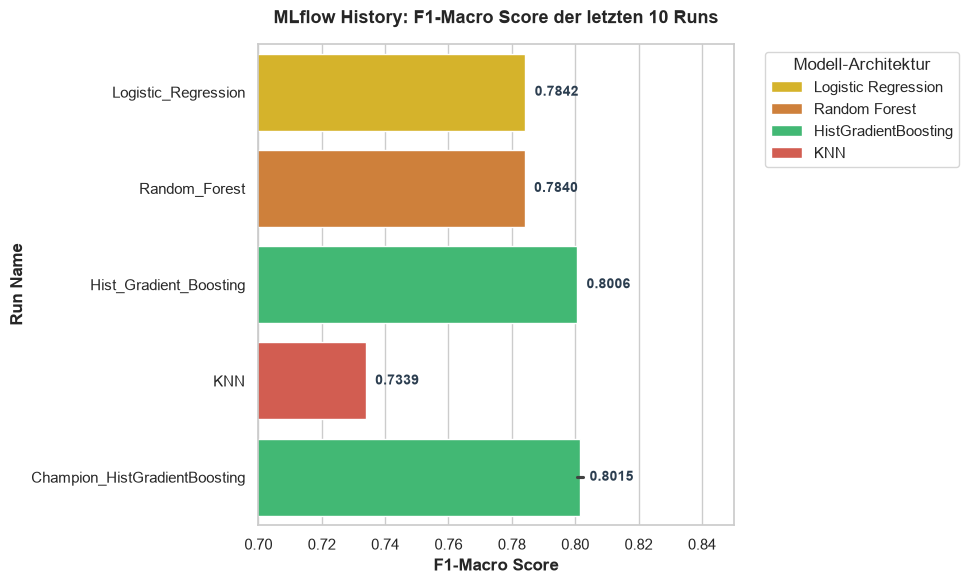

In [56]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Runs abrufen und auf die letzten 10 beschränken
experiment = mlflow.get_experiment_by_name("personality-prediction")
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    max_results=10,
    order_by=["attribute.start_time DESC"]
)

# 2. Relevante Spalten filtern & Daten säubern
results_df = runs_df[["tags.mlflow.runName", "metrics.f1_macro"]].dropna().copy()
results_df.columns = ["Run_Name", "F1_Macro"]

# Modell-Typ aus dem Run-Namen extrahieren (für die Farbcodierung)
def extract_model_type(name):
    if "KNN" in name: return "KNN"
    if "Random_Forest" in name or "RF" in name: return "Random Forest"
    if "Logistic" in name or "LR" in name: return "Logistic Regression"
    if "Hist_Gradient" in name or "Champion" in name: return "HistGradientBoosting"
    return "Sonstige"

results_df["Model_Family"] = results_df["Run_Name"].apply(extract_model_type)

# Chronologisch ordnen (ältester oben, neuester unten)
results_df = results_df.iloc[::-1].reset_index(drop=True)

# 3. Visualisierung
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Farbpalette für die Architekturen definieren
palette = {
    "KNN": "#e74c3c",                  # Rot
    "Random Forest": "#e67e22",        # Orange
    "Logistic Regression": "#f1c40f",  # Gelb
    "HistGradientBoosting": "#2ecc71" # Grün (Gewinner-Familie)
}

# Horizontaler Barplot für saubere Abstände ohne Überlappung
ax = sns.barplot(
    data=results_df,
    x="F1_Macro",
    y="Run_Name",
    hue="Model_Family",
    palette=palette,
    dodge=False
)

# X-Achse fokussieren, um Unterschiede sichtbar zu machen
plt.xlim(0.70, 0.85)

# Werte direkt rechts neben den Balken platzieren
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{width:.4f}',
            (width + 0.003, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontsize=10, fontweight='bold', color='#2c3e50'
        )

plt.title("MLflow History: F1-Macro Score der letzten 10 Runs", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("F1-Macro Score", fontweight="bold")
plt.ylabel("Run Name", fontweight="bold")
plt.legend(title="Modell-Architektur", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("data/mlflow_last_10_runs.png", dpi=300, bbox_inches='tight')
plt.show()